# Datenbereinigung für Datenbank Airbnb NYC

In diesem Notebook werden alle Schritte und Überlegungen erarbeitet, die mit der Datenbank PostgreSQL zu tun haben. Dazu werden Spalten der Datei `listings.csv.gz` aufbereitet, gelöscht, Features erstellt und Ansichten VIEWs entwickelt, die dann in csv-Dateien exportiert werden und in Pandas-Dataframes nutzbar sind. Dazu wurde vor allem auch die Darstellung auf Github bedacht und die sparsame Bereitstellung von (großen) Datenmengen.



# 1. Tabelle in DB anlegen

#### a) Weg 1: Tabelle direkt im Query-tool von PGAdmin erstellen

```sql

CREATE TABLE nyc_airbnb_listings_raw (
    -- 1. IDENTIFIKATION UND LAGE
    id BIGINT PRIMARY KEY,
    city VARCHAR(50) NOT NULL, -- Flexibilität für weitere Städte (z.B. Berlin, Paris)
    latitude DOUBLE PRECISION NOT NULL,
    longitude DOUBLE PRECISION NOT NULL,

    -- 2. ZIELVARIABLE UND KATEGORIEN
    price NUMERIC(10, 2) NOT NULL,
    room_type VARCHAR(50) NOT NULL, 
    neighbourhood_group_cleansed VARCHAR(50), 
    
    -- 3. UNTERKUNFT-SPEZIFISCHE FEATURES
    accommodates INTEGER NOT NULL,
    bedrooms INTEGER,
    beds INTEGER,
    bathrooms NUMERIC(3, 1), -- Erlaubt halbe Badezimmer (z.B. 1.5)
    minimum_nights INTEGER NOT NULL,
    availability_365 INTEGER NOT NULL,

    -- 4. BINÄRE UND HOST-INFOS
    instant_bookable BOOLEAN NOT NULL,
    host_is_superhost BOOLEAN, 
    host_total_listings_count INTEGER,

    -- 5. BEWERTUNGEN
    review_scores_rating NUMERIC(4, 2) 
);

#### b) Weg 2: Tabelle aus dem Jupyter Notebook heraus anlegen

Schritte: Auslagerung SQL-Code aus a) in SQL-Dateien

- neuer Ordner im Projekt: SQL (OK)
- Datei 1 dort ablegen: `01_create_table.sql` (OK)
- Datei 2 dort ablegen: `02_create_view_NYC.sql` (OK)
- Verbindung zu Datenbank herstellen und Engine starten (Schritt 1 unten)
- Hilfsfunktionen zum Anzeigen und Einlesen von SQL-Dateien

Schritt 1: Verbindung zur Datenbank herstellen

Erklärung: 
- Datenbank (PostgreSQL/pgAdmin) ist ein "verschlossenes Lagerhaus"
- `db_config.json`: Das ist dein "Ausweis" und der "Schlüssel". Darin steht, wer du bist und wo das "Lagerhaus" steht. Aus Sicherheitsgrüdnen sind die Zugangsdaten in einem separaten .json-File.
- `create_engine`: Bau einer direkten Telefonleitung oder einer Schiene von deinem Laptop (Jupyter Notebook) zu diesem "Lagerhaus".
- `engine`: Das ist das "Telefon" selbst. Solange dieses Objekt in deinem Notebook existiert, kannst du Befehle rufen und Daten schicken.

In [1]:
import json
from sqlalchemy import create_engine
from sqlalchemy import text

# ---------------------------------------------
# SCHRITT A: Secrets aus der Konfigurationsdatei laden (Sicherheits-Layer)
# ---------------------------------------------
try:
    # Stellen Sie sicher, dass 'db_config.json' im gleichen Ordner wie das Notebook liegt
    with open('db_config.json', 'r') as f:
        config = json.load(f)
except FileNotFoundError:
    print("FEHLER: db_config.json nicht gefunden. Bitte prüfen Sie den Pfad.")
    # Platzhalter, falls die Datei nicht geladen werden kann (Bitte ersetzen!)
    config = {
        "DB_USER": "postgres",
        "DB_PASSWORD": "Ihr_Passwort", 
        "DB_NAME": "Airbnb",
        "DB_HOST": "localhost",
        "DB_PORT": "5432"
    }

# ---------------------------------------------
# SCHRITT B: Engine erstellen (SQLAlchemy)
# ---------------------------------------------

DB_USER = config['DB_USER']
DB_PASSWORD = config['DB_PASSWORD']
DB_HOST = config['DB_HOST']
DB_PORT = config['DB_PORT']
DB_NAME = config['DB_NAME']

# Erstellen der Engine/Verbindungszeichenkette
engine = create_engine(
    f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

print(f"✅ SQLAlchemy-Engine für Datenbank '{DB_NAME}' erfolgreich erstellt.")

✅ SQLAlchemy-Engine für Datenbank 'Airbnb' erfolgreich erstellt.


Schritt 2: Hilfsfunktionen

Die unten eingefügten Code-Zeilen mit den Funktionen `def get_sql_code` und `def display_sql_file` verweisen auf die .sql-files im Ordner SQL und stellen die Inhalte schön dar (`display`).

In [2]:
# Funktion zum Einlesen der SQL-Datei
def get_sql_code(path):
    with open(path, 'r', encoding='utf-8') as f:
        return f.read()

# Pfad zu deiner Datei (.. geht einen Ordner hoch aus 'notebooks' in 'sql')
table_sql = get_sql_code('../sql/01_create_table.sql')

# Anzeige im Notebook (formatiert)
from IPython.display import Markdown
Markdown(f"### Verwendetes Datenbankschema\n```sql\n{table_sql}\n```")

### Verwendetes Datenbankschema
```sql
-- Tabelle Erstellen für NYC in PGAdmin

DROP TABLE IF EXISTS nyc_airbnb_listings_raw CASCADE;

CREATE TABLE nyc_airbnb_listings_raw (
    -- 1. IDENTIFIKATION UND LAGE
    id BIGINT PRIMARY KEY,
    city VARCHAR(50) NOT NULL, -- Flexibilität für weitere Städte (z.B. Berlin, Paris)
    latitude DOUBLE PRECISION NOT NULL,
    longitude DOUBLE PRECISION NOT NULL,

    -- 2. ZIELVARIABLE UND KATEGORIEN
    price NUMERIC(10, 2) NOT NULL,
    room_type VARCHAR(50) NOT NULL, 
    neighbourhood_group_cleansed VARCHAR(50), 
    
    -- 3. UNTERKUNFT-SPEZIFISCHE FEATURES
    accommodates INTEGER NOT NULL,
    bedrooms INTEGER,
    beds INTEGER,
    bathrooms NUMERIC(3, 1), -- Erlaubt halbe Badezimmer (z.B. 1.5)
    minimum_nights INTEGER NOT NULL,
    availability_365 INTEGER NOT NULL,

    -- 4. BINÄRE UND HOST-INFOS
    instant_bookable BOOLEAN NOT NULL,
    host_is_superhost BOOLEAN, 
    host_total_listings_count INTEGER,

    -- 5. BEWERTUNGEN
    review_scores_rating NUMERIC(4, 2) 
);
```

In [3]:
# Hilfsfunktion zum Anzeigen von SQL-Dateien im Notebook
def display_sql_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        sql_code = f.read()
    print(f"--- Inhalt von {file_path} ---")
    # Markdown-Anzeige für schönes Syntax-Highlighting
    from IPython.display import Markdown
    return Markdown(f"```sql\n{sql_code}\n```")

# Aufruf der Dateien
display_sql_file('../sql/01_create_table.sql')

--- Inhalt von ../sql/01_create_table.sql ---


```sql
-- Tabelle Erstellen für NYC in PGAdmin

DROP TABLE IF EXISTS nyc_airbnb_listings_raw CASCADE;

CREATE TABLE nyc_airbnb_listings_raw (
    -- 1. IDENTIFIKATION UND LAGE
    id BIGINT PRIMARY KEY,
    city VARCHAR(50) NOT NULL, -- Flexibilität für weitere Städte (z.B. Berlin, Paris)
    latitude DOUBLE PRECISION NOT NULL,
    longitude DOUBLE PRECISION NOT NULL,

    -- 2. ZIELVARIABLE UND KATEGORIEN
    price NUMERIC(10, 2) NOT NULL,
    room_type VARCHAR(50) NOT NULL, 
    neighbourhood_group_cleansed VARCHAR(50), 
    
    -- 3. UNTERKUNFT-SPEZIFISCHE FEATURES
    accommodates INTEGER NOT NULL,
    bedrooms INTEGER,
    beds INTEGER,
    bathrooms NUMERIC(3, 1), -- Erlaubt halbe Badezimmer (z.B. 1.5)
    minimum_nights INTEGER NOT NULL,
    availability_365 INTEGER NOT NULL,

    -- 4. BINÄRE UND HOST-INFOS
    instant_bookable BOOLEAN NOT NULL,
    host_is_superhost BOOLEAN, 
    host_total_listings_count INTEGER,

    -- 5. BEWERTUNGEN
    review_scores_rating NUMERIC(4, 2) 
);
```

Schritt 3: Den Bauplan aus dem Notebook an die DB senden

- Wir nutzen die "Telefonleitung" (engine), um den Inhalt der Datei `01_create_table.sql` an das "Lagerhaus" (Datenbank) zu schicken.
- Fürs Verständnis: Das Query-Tool in pgAdmin macht nichts anderes. Wenn du dort auf "Play" drückst, kopiert pgAdmin den Text und schickt ihn an die Datenbank. Wir machen das jetzt nur automatisiert über Python.

In [4]:
# 1. Wir laden den Inhalt der Datei in eine Variable
sql_befehl = get_sql_code('../sql/01_create_table.sql')

# 2. 'with engine.connect()' öffnet kurz die Leitung und schließt sie danach wieder
with engine.connect() as connection:
    # Wir sagen der Datenbank: "Führe diesen Text aus!"
    connection.execute(text(sql_befehl))
    print("Die Tabelle wurde in der Datenbank angelegt!")

Die Tabelle wurde in der Datenbank angelegt!


## 2. Datenaufbereitung für DB

Rohdaten zu NYC von *Inside Airbnb*

In [13]:
import pandas as pd



In [14]:
import sys
import os

# Definiert den relativen Pfad zum 'src' Ordner
# .. = Ein Ordner hoch zum Projekt-Root
# /src = Dann in den Ordner src
src_path = os.path.join(os.getcwd(), '..', 'src')

# Fügt diesen Pfad dem Python-Suchpfad hinzu
if src_path not in sys.path:
    sys.path.append(src_path)

print(f"✅ src-Ordner temporär zum Suchpfad hinzugefügt: {src_path}")

✅ src-Ordner temporär zum Suchpfad hinzugefügt: c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\notebooks\..\src


In [7]:
df = pd.read_csv("../data/raw/listings_NYC_raw.csv")

In [8]:
df.shape

(36261, 85)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36261 entries, 0 to 36260
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36261 non-null  int64  
 1   listing_url                                   36261 non-null  object 
 2   scrape_id                                     36261 non-null  int64  
 3   last_scraped                                  36261 non-null  object 
 4   source                                        36261 non-null  object 
 5   name                                          36259 non-null  object 
 6   description                                   34893 non-null  object 
 7   neighborhood_overview                         18130 non-null  object 
 8   picture_url                                   36261 non-null  object 
 9   host_id                                       36261 non-null 

#### Fehlende Werte im Datensatz prüfen

In [10]:
missing_values = df.isnull().sum()
# Nur Spalten anzeigen, bei denen mehr als 0 Werte fehlen
print(missing_values[missing_values > 0])

name                               2
description                     1368
neighborhood_overview          18131
host_profile_id                  405
host_profile_url                 405
host_name                         11
host_since                        11
hosts_time_as_user_years         416
hosts_time_as_user_months        416
hosts_time_as_host_years         849
hosts_time_as_host_months        849
host_location                   7868
host_about                     15483
host_response_time             15173
host_response_rate             15173
host_acceptance_rate           14741
host_thumbnail_url                11
host_picture_url                  11
host_neighbourhood              7379
host_listings_count               11
host_total_listings_count         11
host_verifications                11
host_has_profile_pic              11
host_identity_verified            11
neighbourhood                  18130
bathrooms                      14806
bathrooms_text                   108
b

In [17]:
df['price'].isnull().sum()

np.int64(36261)

In [ ]:
df.shape

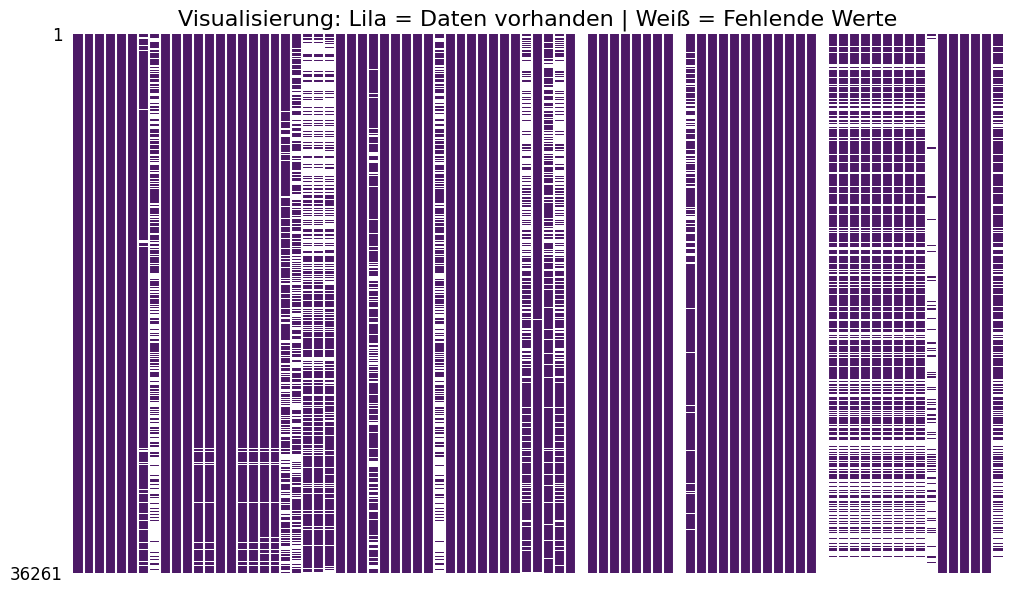

In [11]:
import missingno as msno
import matplotlib.pyplot as plt

# 1. Eine Grafik-Figur erstellen
fig, ax = plt.subplots(figsize=(12, 7))

# 2. Den Hintergrund gelb einfärben (für die fehlenden Werte)
ax.set_facecolor('#FFFF00') # Ein kräftiges Gelb

# 3. Die Matrix zeichnen (Lila für vorhandene Daten)
# color=(0.3, 0.1, 0.4) ist das dunkle Lila
msno.matrix(df, ax=ax, color=(0.3, 0.1, 0.4), sparkline=False, fontsize=10)

plt.title("Visualisierung: Lila = Daten vorhanden | Weiß = Fehlende Werte", fontsize=16)
plt.show()

In [12]:
print(df.columns.tolist())
#print("-" * 50)

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minim

## Schritt 1: Spalten reduzieren

In [13]:
SQL_COLUMNS = [
    'id',
    'price',
    'accommodates',
    'room_type',
    'bedrooms',
    'beds',
    'bathrooms',  
    'neighbourhood_group_cleansed',
    'minimum_nights',
    'instant_bookable',
    'review_scores_rating',
    'host_is_superhost',
    'host_total_listings_count',
    'availability_365',
    'latitude',
    'longitude'

]

df1 = df[SQL_COLUMNS].copy()

In [14]:
df1.head()


,id,price,accommodates,room_type,bedrooms,beds,bathrooms,neighbourhood_group_cleansed,minimum_nights,instant_bookable,review_scores_rating,host_is_superhost,host_total_listings_count,availability_365,latitude,longitude
0,2539,NaN,2,Private room,1.0,NaN,NaN,Brooklyn,30,f,4.89,f,13.0,364,40.64529,-73.97238
1,2595,NaN,1,Entire home/apt,0.0,1.0,1.0,Manhattan,30,f,4.68,f,9.0,319,40.75356,-73.98559
2,6848,NaN,3,Entire home/apt,2.0,1.0,1.0,Brooklyn,30,f,4.60,t,1.0,261,40.70935,-73.95342
3,6872,NaN,1,Private room,1.0,1.0,1.0,Manhattan,30,f,5.00,f,2.0,83,40.80107,-73.94255
4,6990,NaN,1,Private room,2.0,2.0,1.0,Manhattan,30,f,4.88,f,6.0,126,40.78778,-73.94759


In [15]:
df1.tail()

,id,price,accommodates,room_type,bedrooms,beds,bathrooms,neighbourhood_group_cleansed,minimum_nights,instant_bookable,review_scores_rating,host_is_superhost,host_total_listings_count,availability_365,latitude,longitude
36256,1567403299676323885,NaN,2,Entire home/apt,1.0,1.0,1.0,Manhattan,30,f,NaN,f,1.0,113,40.72932,-74.00551
36257,1567443344632413536,NaN,2,Entire home/apt,1.0,1.0,1.0,Manhattan,30,f,NaN,f,21.0,350,40.74536,-74.00274
36258,1567445948159672900,NaN,2,Private room,1.0,NaN,1.0,Manhattan,1,t,NaN,f,3.0,98,40.76460,-73.98131
36259,1567445949142407383,NaN,2,Private room,1.0,NaN,1.0,Manhattan,1,t,NaN,f,3.0,98,40.76460,-73.98131
36260,1567463073250285720,NaN,3,Entire home/apt,0.0,1.0,1.0,Manhattan,30,f,NaN,f,138.0,365,40.73984,-73.98166


## Schritt 2: Zeilen ohne Preis entfernen und Datentyp anpassen

In [16]:
df2 = df1.dropna(subset=['price']).copy()
print(f"Zeilen nach der Preislöschung: {len(df2)}")

Zeilen nach der Preislöschung: 0


In [12]:
# 1. Entfernen von Währungszeichen ($), Kommas (,) und Leerzeichen
df2['price'] = df2['price'].astype(str).str.replace(r'[$,\s]', '', regex=True)

# 2. Konvertieren zu numerischem Float
# Wichtig: errors='coerce' verwandelt Einträge, die nicht konvertiert werden können (z.B. leere Zellen, 'N/A'), in NaN.
df2['price'] = pd.to_numeric(df2['price'], errors='coerce')

# 3b. NEU: Nachbereinigung, falls 'coerce' neue NaN-Werte erzeugt hat
rows_before = len(df2)
df2.dropna(subset=['price'], inplace=True)
rows_after = len(df2)

if rows_before > rows_after:
    print(f"⚠️ ACHTUNG: {rows_before - rows_after} Zeilen wurden nach der String-Bereinigung entfernt, da sie nicht numerisch waren.")
    print(f"Neue Zeilenanzahl: {rows_after}")

## Schritt 3: Binare Spalten konvertieren

Spalten: instant_bookable, host_is_superhost

In [13]:
from IPython.display import display
display(df2[['instant_bookable', 'host_is_superhost']].head(20))

,instant_bookable,host_is_superhost
0,f,t
4,f,t
5,f,t
7,f,t
8,f,f
9,f,f
10,f,t
11,f,f
12,f,f
14,t,t


In [14]:
unique_values = df2['instant_bookable'].unique()
print("Eindeutige Werte in 'instant_bookable':", unique_values)
print("--- Vollständige Verteilung in 'instant_bookable' (t, f, NaN) ---")
print(df2['instant_bookable'].value_counts(dropna=False))

Eindeutige Werte in 'instant_bookable': ['f' 't']
--- Vollständige Verteilung in 'instant_bookable' (t, f, NaN) ---
instant_bookable
f    15966
t     5362
Name: count, dtype: int64


In [15]:
unique_values1 = df2['host_is_superhost'].unique()
print("Eindeutige Werte in 'host_is_superhost':", unique_values1)
print("--- Vollständige Verteilung in 'host_is_superhost' (t, f, NaN) ---")
print(df2['host_is_superhost'].value_counts(dropna=False))

Eindeutige Werte in 'host_is_superhost': ['t' 'f' nan]
--- Vollständige Verteilung in 'host_is_superhost' (t, f, NaN) ---
host_is_superhost
f      14624
t       6395
NaN      309
Name: count, dtype: int64


a) Umwandlung von 'instant_bookable' in booleschen Typ

In [16]:
 # MAPPING: 't' und 'f' auf True und False mappen
boolean_mapping = {'t': True, 'f': False}

# KONVERTIERUNG: Die .map-Funktion wendet das Dictionary an
# und behält gleichzeitig alle NaN-Werte bei, was gut ist für Spalten, 
# die NULL zulassen (wie host_is_superhost).
df2['instant_bookable'] = df2['instant_bookable'].map(boolean_mapping)

# PRÜFUNG: Kontrolle, welche Werte jetzt vorhanden sind
print("Eindeutige Werte in 'instant_bookable':")
print(df2['instant_bookable'].value_counts(dropna=False))

Eindeutige Werte in 'instant_bookable':
instant_bookable
False    15966
True      5362
Name: count, dtype: int64


b) Umwandlung von 'host_is_superhost' in Boolean

In [17]:
# MAPPING: 't' und 'f' auf True und False mappen
boolean_mapping1 = {'t': True, 'f': False}

# KONVERTIERUNG: Die .map-Funktion wendet das Dictionary an
# und behält gleichzeitig alle NaN-Werte bei, was gut ist für Spalten, 
# die NULL zulassen.
df2['host_is_superhost'] = df2['host_is_superhost'].map(boolean_mapping1)

# PRÜFUNG: Kontrolle, welche Werte jetzt vorhanden sind
print("Eindeutige Werte in 'host_is_superhost':")
print(df2['host_is_superhost'].value_counts(dropna=False))

Eindeutige Werte in 'host_is_superhost':
host_is_superhost
False    14624
True      6395
NaN        309
Name: count, dtype: int64


## Schritt 4: Spalte 'city' ergänzen

In [18]:
df2['city'] = 'NYC'
print("--- Die ersten Zeilen mit der neuen 'city'-Spalte ---")
print(df2[['city', 'price', 'instant_bookable', 'host_is_superhost']].head())

--- Die ersten Zeilen mit der neuen 'city'-Spalte ---
  city  price  instant_bookable host_is_superhost
0  NYC   66.0             False              True
4  NYC   76.0             False              True
5  NYC   97.0             False              True
7  NYC   60.0             False              True
8  NYC  425.0             False             False


## Schritt 5: Bathrooms bereinigen

In [19]:
df2['bathrooms'].unique()

array([ 1. ,  2. ,  4. ,  1.5,  3. ,  2.5,  5. ,  0. ,  nan,  3.5,  0.5,
       15.5, 10.5,  4.5,  5.5,  6. ,  7. ,  7.5,  9. ,  6.5])

In [20]:
df2['bathrooms'].isnull().sum()

np.int64(7)

In [23]:
df2['bathrooms'] = pd.to_numeric(df2['bathrooms'], errors='coerce')
print(f"Datentyp von 'bathrooms' nach Konvertierung: {df2['bathrooms'].dtype}")

Datentyp von 'bathrooms' nach Konvertierung: float64


## Schritt 6: Finale Überprüfung vor Einpflege in die DB

In [24]:
df2.shape

(21328, 17)

In [25]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21328 entries, 0 to 36110
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            21328 non-null  int64  
 1   price                         21328 non-null  float64
 2   accommodates                  21328 non-null  int64  
 3   room_type                     21328 non-null  object 
 4   bedrooms                      21242 non-null  float64
 5   beds                          21287 non-null  float64
 6   bathrooms                     21321 non-null  float64
 7   neighbourhood_group_cleansed  21328 non-null  object 
 8   minimum_nights                21328 non-null  int64  
 9   instant_bookable              21328 non-null  bool   
 10  review_scores_rating          14944 non-null  float64
 11  host_is_superhost             21019 non-null  object 
 12  host_total_listings_count     20284 non-null  float64
 13  availa

[Data Dictionary](https://docs.google.com/spreadsheets/d/116R-QwHH8gGSLItQV7PPvEJBxDXbEOxg93yDzJYcNHY/edit?gid=0#gid=0)


## Schritt 7: Export in Ordner Data/interim

In [26]:
import os

# 1. Definieren des Zielpfads
base_path = r'C:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\data'
file_name = 'nyc_airbnb_prepared_for_sql.csv'
target_folder = 'interim'

# Den vollständigen Pfad erstellen (nutzt os.path.join für korrekte Schrägstriche)
full_path = os.path.join(base_path, target_folder, file_name)

# 2. Export des DataFrames
# index=False ist WICHTIG, damit Pandas die Zeilennummern (den Index) 
# NICHT als zusätzliche Spalte in die CSV-Datei schreibt.
df2.to_csv(full_path, index=False)

print("--- Export-Bestätigung ---")
print(f"✅ DataFrame wurde erfolgreich exportiert nach:")
print(full_path)

--- Export-Bestätigung ---
✅ DataFrame wurde erfolgreich exportiert nach:
C:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\data\interim\nyc_airbnb_prepared_for_sql.csv


In [27]:
df_check = pd.read_csv("../data/interim/nyc_airbnb_prepared_for_sql.csv")

In [28]:
df_check.head()

,id,price,accommodates,room_type,bedrooms,beds,bathrooms,neighbourhood_group_cleansed,minimum_nights,instant_bookable,review_scores_rating,host_is_superhost,host_total_listings_count,availability_365,latitude,longitude,city
0,40824219,66.0,1,Private room,1.0,1.0,1.0,Queens,30,False,4.81,True,3.0,77,40.746980,-73.917630,NYC
1,40839416,76.0,1,Private room,1.0,1.0,2.0,Manhattan,30,False,4.95,True,16.0,168,40.721470,-73.982700,NYC
2,40843980,97.0,6,Entire home/apt,2.0,3.0,1.0,Queens,30,False,4.14,True,2.0,364,40.682300,-73.845450,NYC
3,40824301,60.0,1,Private room,2.0,1.0,1.0,Brooklyn,30,False,4.92,True,1.0,187,40.713163,-73.943077,NYC
4,40825740,425.0,6,Entire home/apt,3.0,3.0,4.0,Brooklyn,30,False,5.00,False,9.0,224,40.674120,-73.941230,NYC


In [29]:
df_check.columns.tolist()

['id',
 'price',
 'accommodates',
 'room_type',
 'bedrooms',
 'beds',
 'bathrooms',
 'neighbourhood_group_cleansed',
 'minimum_nights',
 'instant_bookable',
 'review_scores_rating',
 'host_is_superhost',
 'host_total_listings_count',
 'availability_365',
 'latitude',
 'longitude',
 'city']

## Schritt 8: Export in DB

In [11]:
import json
from sqlalchemy import create_engine

# ---------------------------------------------
# SCHRITT A: Secrets aus der Konfigurationsdatei laden (Sicherheits-Layer)
# ---------------------------------------------
try:
    # Stellen Sie sicher, dass 'db_config.json' im gleichen Ordner wie das Notebook liegt
    with open('db_config.json', 'r') as f:
        config = json.load(f)
except FileNotFoundError:
    print("FEHLER: db_config.json nicht gefunden. Bitte prüfen Sie den Pfad.")
    # Platzhalter, falls die Datei nicht geladen werden kann (Bitte ersetzen!)
    config = {
        "DB_USER": "postgres",
        "DB_PASSWORD": "Ihr_Passwort", 
        "DB_NAME": "Airbnb",
        "DB_HOST": "localhost",
        "DB_PORT": "5432"
    }

# ---------------------------------------------
# SCHRITT B: Engine erstellen (SQLAlchemy)
# ---------------------------------------------

DB_USER = config['DB_USER']
DB_PASSWORD = config['DB_PASSWORD']
DB_HOST = config['DB_HOST']
DB_PORT = config['DB_PORT']
DB_NAME = config['DB_NAME']

# Erstellen der Engine/Verbindungszeichenkette
engine = create_engine(
    f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

print(f"✅ SQLAlchemy-Engine für Datenbank '{DB_NAME}' erfolgreich erstellt.")

✅ SQLAlchemy-Engine für Datenbank 'Airbnb' erfolgreich erstellt.


In [12]:
# Definieren des Zieltabellennamens in der Datenbank
TABLE_NAME = 'nyc_airbnb_listings_raw'

# Importieren des DataFrames in die Datenbank
# if_exists='replace': Löscht die Tabelle, falls sie existiert, und erstellt sie neu.
# index=False: Verhindert, dass der Pandas-Index als Spalte importiert wird.
try:
    df2.to_sql(
        name=TABLE_NAME, 
        con=engine, 
        if_exists='replace', 
        index=False,
        chunksize=10000 # Importiert in Blöcken für bessere Performance
    )
    print(f"✅ Daten erfolgreich in die Tabelle '{TABLE_NAME}' in der Datenbank '{DB_NAME}' importiert.")

except Exception as e:
    print(f"❌ FEHLER beim Import. Bitte überprüfen Sie:")
    print(f"1. Ist der PostgreSQL-Server aktiv?")
    print(f"2. Ist der Tabellenname '{TABLE_NAME}' korrekt?")
    print(f"Fehlerdetails: {e}")

❌ FEHLER beim Import. Bitte überprüfen Sie:
1. Ist der PostgreSQL-Server aktiv?
2. Ist der Tabellenname 'nyc_airbnb_listings_raw' korrekt?
Fehlerdetails: name 'df2' is not defined


In [33]:
engine.dispose()
print("✅ SQLAlchemy Engine und alle verbundenen Ressourcen geschlossen.")

✅ SQLAlchemy Engine und alle verbundenen Ressourcen geschlossen.


# 2. VIEW erstellen für NYC Lineare Regression

In [2]:
import pandas as pd

In [15]:
df = pd.read_csv("../data/interim/NYC_airbnb_prepared_for_sql.csv")

Eine SQL-View wird in PostgreSQL erstellt, um die Feature-Selection und Distanzberechnungen durchzuführen (Haversine erkennbar an 6371 (Erdradius), Angabe in km)

```sql
CREATE VIEW vw_airbnb_model_data AS
SELECT 
    id,
    neighbourhood_group_cleansed,
    room_type,
    instant_bookable,
    accommodates,
    bathrooms,
    bedrooms,
    beds,
    host_total_listings_count,
    -- Berechnung der Distanz zum Times Square (Haversine-Formel)
    (6371 * acos(
        cos(radians(40.7580)) * cos(radians(latitude)) * cos(radians(longitude) - radians(-73.9855)) + 
        sin(radians(40.7580)) * sin(radians(latitude))
    )) AS distance_to_center,
    price,
    LN(price + 1) AS ln_price
FROM nyc_airbnb_listings_raw
WHERE price > 0 
  AND price <= 564;
```

### Daten aus der VIEW in ein .csv laden und lokal abspeichern

In [16]:
import pandas as pd
from sqlalchemy import create_engine, text
import json
import os

# 1. Konfiguration laden (Schritt 1 ersetzt durch JSON)
try:
    with open('db_config.json', 'r') as f:
        config = json.load(f)

    # Verbindung herstellen mit f-String
    engine = create_engine(
        f"postgresql://{config['DB_USER']}:{config['DB_PASSWORD']}@{config['DB_HOST']}:{config['DB_PORT']}/{config['DB_NAME']}"
    )
    print("✅ Verbindungskonfiguration geladen.")

    # 2. VIEW aufrufen und als DataFrame laden
    query = "SELECT * FROM vw_airbnb_model_data;"
    
    with engine.connect() as connection:
        df_model = pd.read_sql(text(query), connection)
    
    print(f"✅ {len(df_model)} Zeilen aus der View geladen.")

    # 3. Als .csv im passenden Ordner speichern
    output_dir = "../data/processed"
    os.makedirs(output_dir, exist_ok=True)
    
    file_path = os.path.join(output_dir, "airbnb_NYC_model_data.csv")
    df_model.to_csv(file_path, index=False)

    print(f"💾 Datei erfolgreich gespeichert: {file_path}")

except FileNotFoundError:
    print("❌ Fehler: Die Datei 'db_config.json' wurde nicht gefunden!")
except Exception as e:
    print(f"❌ Ein Fehler ist aufgetreten: {e}")

✅ Verbindungskonfiguration geladen.
✅ 19808 Zeilen aus der View geladen.
💾 Datei erfolgreich gespeichert: ../data/processed\airbnb_NYC_model_data.csv


### Testaufruf der .csv-Datei in dataframe

In [17]:
df = pd.read_csv('../data/processed/airbnb_NYC_model_data.csv')

In [18]:
df.head

<bound method NDFrame.head of                         id neighbourhood_group_cleansed        room_type  \
0                 40824219                       Queens     Private room   
1                 40839416                    Manhattan     Private room   
2                 40843980                       Queens  Entire home/apt   
3                 40824301                     Brooklyn     Private room   
4                 40825740                     Brooklyn  Entire home/apt   
...                    ...                          ...              ...   
19803  1518145740023617475                    Manhattan  Entire home/apt   
19804  1518194647322488321                    Manhattan  Entire home/apt   
19805  1518232643177537314                    Manhattan  Entire home/apt   
19806  1518345023898568625                    Manhattan  Entire home/apt   
19807  1518352509290380578                    Manhattan  Entire home/apt   

       instant_bookable  accommodates  bathrooms  bedroom